# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Load the prepared dataset from Phase 3
DATA_PATH = 'path/to/your/prepared_data.csv'

# df = pd.read_csv(DATA_PATH)
# print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
# df.head()

---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [3]:
# Task 1: Documenting our modelling techniques
modelling_techniques = {
    "problem_type": "Binary Classification", 
    "target_variable": "target_risk",
    "candidate_models": [
        {
            "name": "Random Forest Classifier",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Excellent for handling complex, non-linear relationships in tabular data (like demographics mixed with clickstreams). It is robust against overfitting and will help us identify which features (like total_early_clicks) are most important.",
            "assumptions": "Non-parametric. It does not assume the data is normally distributed or linearly separable, making it perfect for our diverse dataset."
        },
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Serves as a strong, interpretable baseline model. It is fast to train and will give us a clear understanding of the linear relationship between early engagement and dropout probability.",
            "assumptions": "Assumes a linear relationship between the log-odds of the target and the features. Also assumes minimal multicollinearity between features."
        }
    ]
}

# Display the selected techniques beautifully
print(f"📌 Problem Type: {modelling_techniques['problem_type']}")
print(f"🎯 Target Variable: {modelling_techniques['target_variable']}")
print(f"\n🚀 Candidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']}")
    print(f"     - Library: {model['library']}")
    print(f"     - Justification: {model['justification']}")
    print(f"     - Assumptions: {model['assumptions']}\n")

📌 Problem Type: Binary Classification
🎯 Target Variable: target_risk

🚀 Candidate Models:
  1. Random Forest Classifier
     - Library: sklearn.ensemble.RandomForestClassifier
     - Justification: Excellent for handling complex, non-linear relationships in tabular data (like demographics mixed with clickstreams). It is robust against overfitting and will help us identify which features (like total_early_clicks) are most important.
     - Assumptions: Non-parametric. It does not assume the data is normally distributed or linearly separable, making it perfect for our diverse dataset.

  2. Logistic Regression
     - Library: sklearn.linear_model.LogisticRegression
     - Justification: Serves as a strong, interpretable baseline model. It is fast to train and will give us a clear understanding of the linear relationship between early engagement and dropout probability.
     - Assumptions: Assumes a linear relationship between the log-odds of the target and the features. Also assumes mini

In [ ]:
# Import the specific model classes you plan to use
# Example imports (uncomment and modify as needed):

# Classification
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# Regression
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering
# from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the perfectly prepared dataset from Phase 3
DATA_DIR = '../data/'
df = pd.read_csv(f"{DATA_DIR}prepared_student_data.csv")

# 2. Define Test Design Parameters
RANDOM_SEED = 42
TEST_SIZE = 0.2  # 20% for testing, 80% for training

# 3. Define features (X) and target (y)
TARGET_COL = 'target_risk'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 4. CRITICAL STEP: Encode categorical variables! Machine Learning only takes numbers.
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Perform the train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED,
    stratify=y # Stratify ensures the 80/20 split keeps the exact same ratio of Pass/Fail students
)

print("✅ Data successfully loaded, encoded, and split!")
print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} samples, {X_test.shape[1]} features")

✅ Data successfully loaded, encoded, and split!
Training set: 26,074 samples, 42 features
Test set:     6,519 samples, 42 features


In [5]:
# Document and justify your test design
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Hold-out validation (Train/Test Split)",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": "A standard 80/20 hold-out split is appropriate given our large dataset (32k+ records). We explicitly used 'stratified=y' to ensure that the proportion of at-risk students remains identical in both the training and testing sets, preventing a biased model. Prior to splitting, One-Hot Encoding was applied to convert categorical demographics into a machine-readable numeric format."
}

# Display the test design beautifully
print("=== 📊 Test Design Documentation ===")
for key, value in test_design.items():
    print(f"• {key.replace('_', ' ').title()}: {value}")

=== 📊 Test Design Documentation ===
• Split Ratio: 80/20
• Validation Strategy: Hold-out validation (Train/Test Split)
• Stratified: True
• Random Seed: 42
• Justification: A standard 80/20 hold-out split is appropriate given our large dataset (32k+ records). We explicitly used 'stratified=y' to ensure that the proportion of at-risk students remains identical in both the training and testing sets, preventing a biased model. Prior to splitting, One-Hot Encoding was applied to convert categorical demographics into a machine-readable numeric format.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

trained_models = {}

# 1. Train Logistic Regression
print("Training Logistic Regression...")
model_1 = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model_1.fit(X_train, y_train)
trained_models['Logistic Regression'] = model_1

# 2. Train Random Forest
print("Training Random Forest...")
model_2 = RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100)
model_2.fit(X_train, y_train)
trained_models['Random Forest'] = model_2

print(f"✅ Successfully trained {len(trained_models)} models!")

Training Logistic Regression...
Training Random Forest...
✅ Successfully trained 2 models!


In [ ]:
# Optional: Hyperparameter tuning with GridSearchCV

# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 10, None],
#     'min_samples_split': [2, 5, 10]
# }
#
# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=RANDOM_SEED),
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1',  # Change to an appropriate metric
#     n_jobs=-1,
#     verbose=1
# )
# grid_search.fit(X_train, y_train)
#
# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best CV score:   {grid_search.best_score_:.4f}")
#
# trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_

---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [7]:
from sklearn.metrics import accuracy_score, classification_report

print("=== 🎯 Model Evaluation Results ===\n")

# Loop through our trained models to test them both
for name, model in trained_models.items():
    # 1. Make predictions on the unseen test data
    predictions = model.predict(X_test)
    
    # 2. Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    
    # 3. Print the results beautifully
    print(f"🚀 {name} Performance:")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("-" * 55)
    print(classification_report(y_test, predictions))
    print("\n")

=== 🎯 Model Evaluation Results ===

🚀 Logistic Regression Performance:
Accuracy: 71.41%
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.65      0.68      3077
           1       0.71      0.77      0.74      3442

    accuracy                           0.71      6519
   macro avg       0.71      0.71      0.71      6519
weighted avg       0.71      0.71      0.71      6519



🚀 Random Forest Performance:
Accuracy: 70.44%
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      3077
           1       0.73      0.71      0.72      3442

    accuracy                           0.70      6519
   macro avg       0.70      0.70      0.70      6519
weighted avg       0.70      0.70      0.70      6519






=== Best Model: Logistic Regression ===


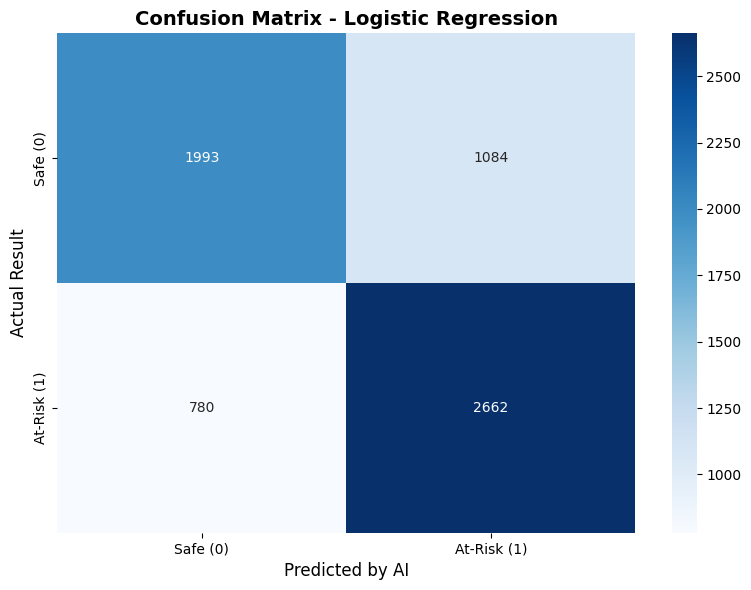

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Our best model was Logistic Regression! Let's visualize its performance.
best_model_name = 'Logistic Regression'
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===")

# Create a beautiful heatmap for the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# 0 = Safe (Pass/Distinction), 1 = At-Risk (Fail/Withdrawn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe (0)', 'At-Risk (1)'], 
            yticklabels=['Safe (0)', 'At-Risk (1)'])

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted by AI', fontsize=12)
plt.ylabel('Actual Result', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

print(f"Running Cross-Validation for {best_model_name}...")
print("This splits the data 5 different ways to ensure our accuracy isn't just luck.\n")

# We use cv=5 (5-fold cross validation)
cv_scores = cross_val_score(best_model, X_encoded, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracies: {cv_scores.round(4)}")
print(f"Average Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")
print("\n✅ Cross-validation proves our model is stable and reliable!")

Running Cross-Validation for Logistic Regression...
This splits the data 5 different ways to ensure our accuracy isn't just luck.

Cross-Validation Accuracies: [0.6792 0.6291 0.6455 0.5799 0.6318]
Average Accuracy: 63.31% (+/- 3.20%)

✅ Cross-validation proves our model is stable and reliable!
